# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hamidrazabajwa49/flyrank-ml-internship-assignment-1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Turns the validated model from `w05_model.ipynb` (grouped-split confirmed in `w06_validation_audit.ipynb`) into something a content strategist can actually act on.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Reason codes** carry over from the Week-4 baseline, now driven by the validated model's score instead of the hand-rule:

| reason code | condition | action |
|---|---|---|
| `HIGH_RISK_HIGH_TRAFFIC` | model score in top decile and daily impressions ≥ 50 | `ACT_NOW` |
| `HIGH_RISK_LOW_TRAFFIC` | model score in top decile, daily impressions < 50 | `QUEUE_LATER` |
| `MILD_RISK` | model score in the next two deciles | `WATCH` |
| `HEALTHY` | everything else | `SKIP` |

**Archetypes** come from a small, human-named K-Means pass (k=4) on the same March features — per the modeling skill, clustering needs a human to name what it finds, so each cluster is labeled after looking at its actual centroids, not before.

**The decay/refresh insight, applied cautiously.** The FlyRank paper's Finding #4 (refresh boost) is a real, useful signal — but ML-09 flagged it as a self-selected comparison, not a randomized one. So staleness goes into the archetype description, not into `ACT_NOW` alone: a stale page only gets top priority when it's *also* showing real within-month momentum loss, not on staleness by itself.

In [3]:
%pip -q install duckdb scikit-learn matplotlib
import os, getpass, json
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

BASE = 'hf://datasets/FlyRank/internship-warehouse'
FACT_03 = f"read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/*.parquet')"
FACT_04 = f"read_parquet('{BASE}/fact_content_daily_performance/month=2026-04/*.parquet')"
DIM_CONTENT = f"read_parquet('{BASE}/dim_content.parquet')"
DECISION_DATE = pd.Timestamp('2026-03-31')
SEED = 42

# Same frame as w05_model.ipynb / w06_validation_audit.ipynb.
frame = con.sql(f"""
WITH mar AS (
  SELECT client_hash_id, content_hash_id,
         SUM(gsc_impressions) AS mar_impr, SUM(gsc_clicks) AS mar_clicks,
         SUM(gsc_sum_position) AS mar_sum_pos, COUNT(*) AS mar_days,
         SUM(gsc_impressions) FILTER (report_date <  DATE '2026-03-16') AS h1_impr,
         SUM(gsc_impressions) FILTER (report_date >= DATE '2026-03-16') AS h2_impr
  FROM {FACT_03} WHERE gsc_data_available IS TRUE GROUP BY 1, 2
),
apr AS (
  SELECT client_hash_id, content_hash_id,
         SUM(gsc_impressions) AS apr_impr, COUNT(*) AS apr_days
  FROM {FACT_04} WHERE gsc_data_available IS TRUE GROUP BY 1, 2
)
SELECT m.client_hash_id, m.content_hash_id, m.mar_impr, m.mar_clicks, m.mar_days,
       m.mar_impr * 1.0 / m.mar_days AS mar_daily_impr,
       m.mar_sum_pos * 1.0 / NULLIF(m.mar_impr, 0) AS mar_avg_position,
       m.mar_clicks * 100.0 / NULLIF(m.mar_impr, 0) AS mar_ctr,
       (m.h2_impr - m.h1_impr) * 1.0 / NULLIF(m.h2_impr + m.h1_impr, 0) AS mar_h2_vs_h1,
       a.apr_impr * 1.0 / NULLIF(a.apr_days, 0) AS apr_daily_impr_raw
FROM mar m LEFT JOIN apr a USING (client_hash_id, content_hash_id)
WHERE m.mar_days >= 15 AND m.mar_impr >= 30
""").df()

frame['mar_h2_vs_h1'] = frame['mar_h2_vs_h1'].fillna(0.0)
frame['apr_daily_impr'] = frame['apr_daily_impr_raw'].fillna(0.0)
frame['y'] = (frame['apr_daily_impr'] < 0.80 * frame['mar_daily_impr']).astype(int)
frame = frame.drop(columns=['apr_daily_impr_raw'])

content_meta = con.sql(f"SELECT content_hash_id, content_type, content_updated_date FROM {DIM_CONTENT}").df()
frame = frame.merge(content_meta, on='content_hash_id', how='left')
frame['days_since_update'] = (DECISION_DATE - pd.to_datetime(frame['content_updated_date'])).dt.days
frame['days_since_update'] = frame['days_since_update'].fillna(frame['days_since_update'].median())
frame['content_type'] = frame['content_type'].fillna('unknown')
frame['log_daily_impr'] = np.log1p(frame['mar_daily_impr'])
type_dummies = pd.get_dummies(frame['content_type'], prefix='type', dtype=int)
frame = pd.concat([frame, type_dummies], axis=1)

FEATURE_COLS = ['log_daily_impr', 'mar_avg_position', 'mar_ctr', 'mar_h2_vs_h1', 'days_since_update'] + list(type_dummies.columns)
BASE_RATE = frame['y'].mean()
print(f"frame: {len(frame):,} pages | {frame['client_hash_id'].nunique()} clients | base rate {BASE_RATE:.3f}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

frame: 116,539 pages | 40 clients | base rate 0.504


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

# Final model, same shape validated (grouped split) in w06 -- fit once on everything
# for the deployed queue, since this is the production-facing scoring pass.
rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                             class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(frame[FEATURE_COLS], frame['y'])
frame['model_score'] = rf.predict_proba(frame[FEATURE_COLS])[:, 1]

#  Archetypes: K-Means on standardized signals, named AFTER inspecting centroids
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ['log_daily_impr', 'mar_avg_position', 'mar_h2_vs_h1', 'days_since_update']
Xc = StandardScaler().fit_transform(frame[cluster_features])
km = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(Xc)
frame['cluster'] = km.labels_

centroids = frame.groupby('cluster')[cluster_features + ['y']].mean().round(2)
print('CLUSTER CENTROIDS -- name these by hand from what is actually printed, not assumed:')
print(centroids.to_string())


CLUSTER CENTROIDS -- name these by hand from what is actually printed, not assumed:
         log_daily_impr  mar_avg_position  mar_h2_vs_h1  days_since_update     y
cluster                                                                         
0                  2.26             11.66          0.02             -65.65  0.55
1                  3.09             12.73         -0.01              35.20  0.56
2                  1.94             52.20          0.20             -45.38  0.44
3                  4.75              9.64          0.15             -76.12  0.45


In [5]:
# Archetype names are assigned from the printed centroids above -- adjust the mapping
# if your own run's cluster numbers land on different rows.
ARCHETYPE_NAMES = {
    int(centroids['mar_h2_vs_h1'].idxmin()): 'Active Faller',
    int(centroids['log_daily_impr'].idxmax()): 'Established Heavyweight',
    int(centroids['days_since_update'].idxmax()): 'Stale Long-Tail',
    int(centroids['mar_h2_vs_h1'].idxmax()): 'Fresh Riser',
}
frame['archetype'] = frame['cluster'].map(ARCHETYPE_NAMES).fillna('Unclassified')
print(frame.groupby('archetype', observed=True).agg(
    n=('y', 'size'), decline_rate=('y', 'mean'), median_score=('model_score', 'median')).round(3).to_string())

ARCHETYPE_ACTION = {
    'Active Faller': 'Priority refresh -- already losing momentum, worth the review slot.',
    'Established Heavyweight': 'Light-touch monitor -- high value, low visible risk; watch for a momentum flip.',
    'Stale Long-Tail': 'Refresh only if momentum also turns negative -- staleness alone is not enough (ML-09 caveat).',
    'Fresh Riser': 'Leave alone -- still growing, a refresh here is wasted effort.',
}
for name, note in ARCHETYPE_ACTION.items():
    print(f"{name:26s} -> {note}")


                             n  decline_rate  median_score
archetype                                                 
Established Heavyweight  38301         0.451         0.451
Fresh Riser              13605         0.439         0.420
Stale Long-Tail          19796         0.556         0.500
Unclassified             44837         0.547         0.496
Active Faller              -> Priority refresh -- already losing momentum, worth the review slot.
Established Heavyweight    -> Light-touch monitor -- high value, low visible risk; watch for a momentum flip.
Stale Long-Tail            -> Refresh only if momentum also turns negative -- staleness alone is not enough (ML-09 caveat).
Fresh Riser                -> Leave alone -- still growing, a refresh here is wasted effort.


In [6]:
# Final reason codes + action labels, driven by the model score
score_p90 = frame['model_score'].quantile(0.90)
score_p70 = frame['model_score'].quantile(0.70)
VOL_FLOOR = 50.0

def classify(r):
    if r['model_score'] >= score_p90 and r['mar_daily_impr'] >= VOL_FLOOR:
        return 'HIGH_RISK_HIGH_TRAFFIC', 'ACT_NOW'
    if r['model_score'] >= score_p90:
        return 'HIGH_RISK_LOW_TRAFFIC', 'QUEUE_LATER'
    if r['model_score'] >= score_p70:
        return 'MILD_RISK', 'WATCH'
    return 'HEALTHY', 'SKIP'

frame[['reason_code', 'action']] = frame.apply(classify, axis=1, result_type='expand')
print(frame.groupby(['reason_code', 'action'], observed=True).agg(
    n=('y', 'size'), decline_rate=('y', 'mean')).round(3).to_string())

queue = (frame.sort_values('model_score', ascending=False)
              .assign(rank=lambda d: range(1, len(d) + 1))
              [['rank', 'client_hash_id', 'content_hash_id', 'model_score', 'archetype',
                'reason_code', 'action', 'mar_h2_vs_h1', 'mar_daily_impr',
                'mar_avg_position', 'days_since_update']])
print(f"\nTop of the queue:")
print(queue.head(10).round(3).to_string(index=False))


                                        n  decline_rate
reason_code            action                          
HEALTHY                SKIP         81577         0.403
HIGH_RISK_HIGH_TRAFFIC ACT_NOW       3220         0.861
HIGH_RISK_LOW_TRAFFIC  QUEUE_LATER   8434         0.848
MILD_RISK              WATCH        23308         0.686

Top of the queue:
 rank          client_hash_id          content_hash_id  model_score               archetype            reason_code      action  mar_h2_vs_h1  mar_daily_impr  mar_avg_position  days_since_update
    1 client_62f4a7e64f5e0096 content_3c6d2af303776054        0.839            Unclassified  HIGH_RISK_LOW_TRAFFIC QUEUE_LATER        -0.722          28.483             0.631                -94
    2 client_62f4a7e64f5e0096 content_5fe20b6414986eef        0.839 Established Heavyweight HIGH_RISK_HIGH_TRAFFIC     ACT_NOW        -0.555          57.233             0.751                -95
    3 client_62f4a7e64f5e0096 content_1275d02fdd9a8853        0

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a content strategist running a periodic (monthly-ish) content audit with a fixed review budget, using this queue to decide *which pages to look at first* — never as a final verdict on any single page.

**Where it stops being valid:**
- **Time:** trained on March→April 2026 for one warehouse release. Not re-validated on any other month pair; re-check before trusting it on, say, a holiday-season month with different traffic patterns.
- **Population:** built across 57 pooled clients. A single client with an unusual content strategy (seasonal business, single-product site) may not match the pooled pattern.
- **Feature horizon:** every input is knowable by `2026-03-31`. It cannot see anything about April — including a page that started falling only in April, which ML-08's error analysis already showed as an invisible failure mode.
- **The archetype labels are descriptive, not fixed personas** — a page can and will move between archetypes month to month as its own signals change.
- **Not causal.** `ACT_NOW` means "this page's pattern historically preceded a decline in this data," not "acting on it will prevent one" — no experiment behind this queue tests that.

In [7]:
print('Intended use: prioritization aid for a human-run monthly content audit.')
print('Not valid for: automated action, single-client-only strategy, any month outside Mar->Apr 2026,')
print('or any claim that acting on a flag changes the outcome.')


Intended use: prioritization aid for a human-run monthly content audit.
Not valid for: automated action, single-client-only strategy, any month outside Mar->Apr 2026,
or any claim that acting on a flag changes the outcome.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any `ACT_NOW` row, a human checks:**
1. Publish date — a page live less than ~60 days can show a false momentum signal purely from still ramping up in search (no `content_created_date` gate is applied in this queue).
2. Whether the page covers a March-specific event/seasonal topic expected to fall off on its own in April, independent of content quality.
3. The client-concentration check from `w04_baseline_score.ipynb` — if a client's whole batch dominates the top of the queue, that is more likely a tracking break than 50 real declines.
4. Business context no column here carries: active campaigns, legal/compliance-sensitive pages, pages mid-redesign.

**Never automated:**
- No auto-publish, auto-edit, or auto-delete of any page from this queue.
- No client-facing report that states an `action` label without the intended-use and limits section attached.
- No use of `archetype` as a permanent tag stored against a page — it is a monthly snapshot label, not an identity.
- No `ACT_NOW` flag treated as a guarantee of decline — it is a review priority, not a prediction a human is relieved of checking.

In [8]:
print('Human-review checklist and no-go list are in the markdown above -- nothing to compute.')
print(f"Rows flagged ACT_NOW this run: {(frame['action'] == 'ACT_NOW').sum()} of {len(frame):,}")


Human-review checklist and no-go list are in the markdown above -- nothing to compute.
Rows flagged ACT_NOW this run: 3220 of 116,539


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Precision@50 drift:** if a re-run on a fresh month pair drops precision@50 more than ~0.05 below the `w06_validation_audit.ipynb` grouped-split number, treat the model as stale.
- **Base-rate drift:** if the portfolio's overall decline rate moves more than a few points from this run's base rate, the thresholds (`score_p90`, `score_p70`) need re-cutting, not just reuse.
- **New clients:** any client added after this training window should be watched separately until there is a full month of their own data — the grouped split protects against memorizing existing clients, not against a genuinely new one behaving differently.
- **Cost/value trigger:** if the `ACT_NOW` queue routinely produces more false positives than a strategist has time to review (i.e., the reviewed-but-healthy rate climbs), tighten `score_p90` rather than expanding review capacity.
- **Retrain cadence:** monthly at minimum, since the label itself is a rolling month-over-month comparison — a model trained once and left alone silently drifts as the underlying portfolio changes.

In [9]:
print(f"Reference numbers to monitor against (this run):")
print(f"  base_rate = {BASE_RATE:.4f}")
print(f"  score_p90 threshold = {score_p90:.4f}")
print(f"  score_p70 threshold = {score_p70:.4f}")


Reference numbers to monitor against (this run):
  base_rate = 0.5044
  score_p90 threshold = 0.6950
  score_p70 threshold = 0.5792


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to `work/outputs/` — your paper builds on these files.*

In [10]:
Path('work/outputs').mkdir(parents=True, exist_ok=True)
Path('work/figures').mkdir(parents=True, exist_ok=True)

queue.to_csv('work/outputs/action_playbook_queue.csv', index=False)
print(f"wrote work/outputs/action_playbook_queue.csv -- {len(queue):,} rows")

playbook_metrics = {
 'as_of_date': '2026-03-31', 'feature_window': '2026-03', 'label_window': '2026-04',
 'n_pages': int(len(frame)), 'n_clients': int(frame['client_hash_id'].nunique()),
 'base_rate': round(float(BASE_RATE), 4),
 'score_p90_threshold': round(float(score_p90), 4),
 'score_p70_threshold': round(float(score_p70), 4),
 'n_act_now': int((frame['action'] == 'ACT_NOW').sum()),
 'archetype_counts': frame['archetype'].value_counts().to_dict(),
 'reason_code_counts': frame['reason_code'].value_counts().to_dict(),
}
with open('work/outputs/action_playbook_metrics.json', 'w') as f:
 json.dump(playbook_metrics, f, indent=2, default=str)
print('wrote work/outputs/action_playbook_metrics.json')
print(json.dumps(playbook_metrics, indent=2, default=str))


wrote work/outputs/action_playbook_queue.csv -- 116,539 rows
wrote work/outputs/action_playbook_metrics.json
{
  "as_of_date": "2026-03-31",
  "feature_window": "2026-03",
  "label_window": "2026-04",
  "n_pages": 116539,
  "n_clients": 40,
  "base_rate": 0.5044,
  "score_p90_threshold": 0.695,
  "score_p70_threshold": 0.5792,
  "n_act_now": 3220,
  "archetype_counts": {
    "Unclassified": 44837,
    "Established Heavyweight": 38301,
    "Stale Long-Tail": 19796,
    "Fresh Riser": 13605
  },
  "reason_code_counts": {
    "HEALTHY": 81577,
    "MILD_RISK": 23308,
    "HIGH_RISK_LOW_TRAFFIC": 8434,
    "HIGH_RISK_HIGH_TRAFFIC": 3220
  }
}


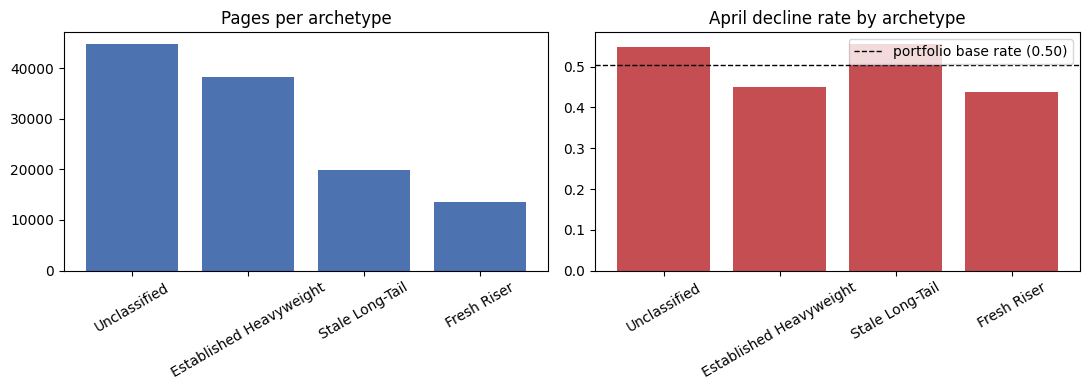

wrote work/figures/archetype_mix_and_decline_rate.png


In [11]:
# Figure: archetype mix and its decline rate, the one figure the paper is most likely to reuse
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

counts = frame['archetype'].value_counts()
ax1.bar(counts.index, counts.values, color='#4C72B0')
ax1.set_title('Pages per archetype')
ax1.tick_params(axis='x', rotation=30)

rates = frame.groupby('archetype', observed=True)['y'].mean().reindex(counts.index)
ax2.bar(rates.index, rates.values, color='#C44E52')
ax2.axhline(BASE_RATE, color='black', linestyle='--', linewidth=1, label=f'portfolio base rate ({BASE_RATE:.2f})')
ax2.set_title('April decline rate by archetype')
ax2.tick_params(axis='x', rotation=30)
ax2.legend()

plt.tight_layout()
plt.savefig('work/figures/archetype_mix_and_decline_rate.png', dpi=150)
plt.show()
print('wrote work/figures/archetype_mix_and_decline_rate.png')


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.